# Comparative Study of Shallow CNN vs Deep CNN on Fashion-MNIST

**Assignment:** Hands-on assignment focused on implementation, experimentation, and model comparison

**Objective:** Perform a comparative study between a shallow CNN and a deep CNN using Fashion-MNIST. Train both models on the same data, compare their performance, analyze their strengths and weaknesses, and conclude which architecture is more suitable for this classification task.

**By:** Vaibhav Chavan Program: PGDSAIML Batch-1

---

## Part 1: Load and Explore the Dataset

Load the Fashion-MNIST dataset and prepare it for CNN-based image classification.

**Tasks:**
- Load the dataset in Python.
- Print the shape of the training data, test data, and the number of classes.
- Display at least one sample image from each class.
- Normalize the image pixel values.
- Reshape the images appropriately for CNN input.

---

In [1]:
# Load the Fashion-MNIST dataset and prepare it for CNN-based image classification.
# Task 1.1: Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.19.0
Libraries imported successfully!


In [2]:
# Load the Fashion-MNIST dataset and print the shapes of training and test data.
# Task 1.2: Load the dataset and print shapes

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("=" * 50)
print("FASHION-MNIST DATASET SUMMARY")
print("=" * 50)
print(f"x_train shape : {x_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"x_test shape  : {x_test.shape}")
print(f"y_test shape  : {y_test.shape}")
print(f"Image size    : {x_train.shape[1]} x {x_train.shape[2]}")
print(f"Pixel range   : [{x_train.min()}, {x_train.max()}]")
print(f"Data type     : {x_train.dtype}")

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
FASHION-MNIST DATASET SUMMARY
x_train shape : (60000, 28, 28)
y_train shape : (60000,)
x_test shape  : (10000, 28, 28)
y_test shape  : (10000,)
Image size    : 28 x 28
Pixel range   : [0, 255]
Data type     : uint8
Number of classes: 10
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


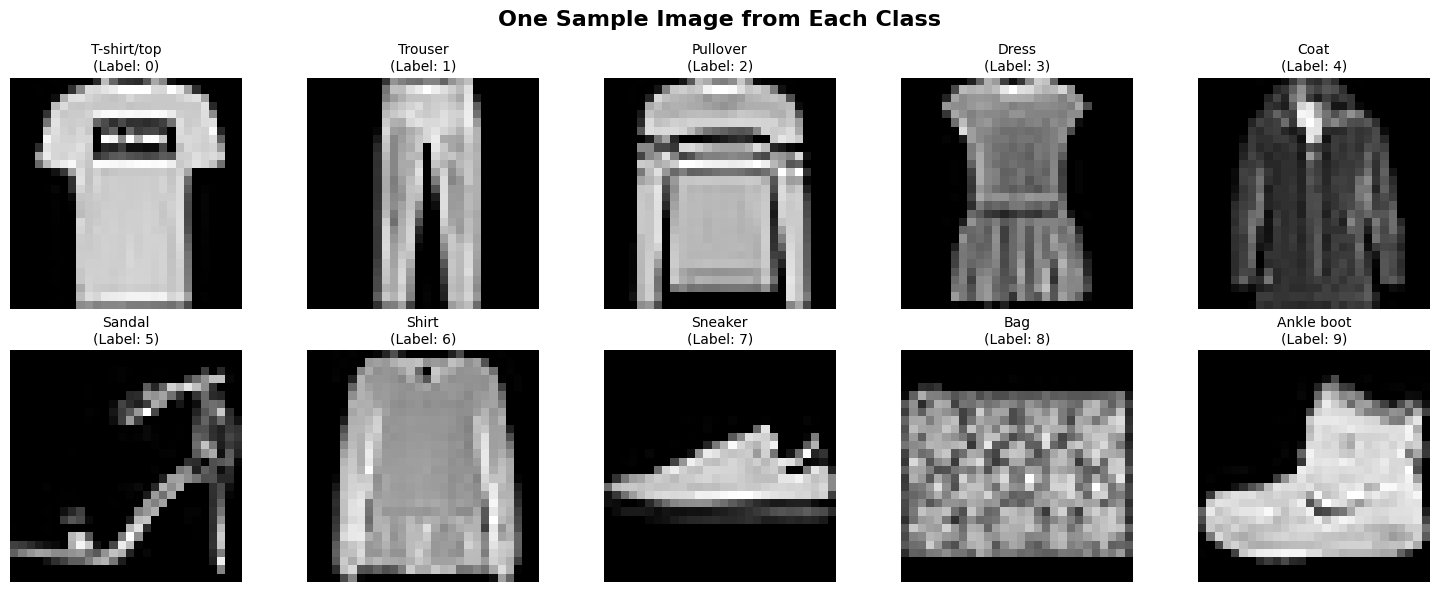

Sample images displayed successfully!


In [3]:
# Display at least one sample image from each class.
# Task 1.3: Display one sample image from each of the 10 classes

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('One Sample Image from Each Class', fontsize=16, fontweight='bold')

for i in range(10):
    # Find the first occurrence of class i
    idx = np.where(y_train == i)[0][0]
    ax = axes[i // 5, i % 5]
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(f'{class_names[i]}\n(Label: {i})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Sample images displayed successfully!")

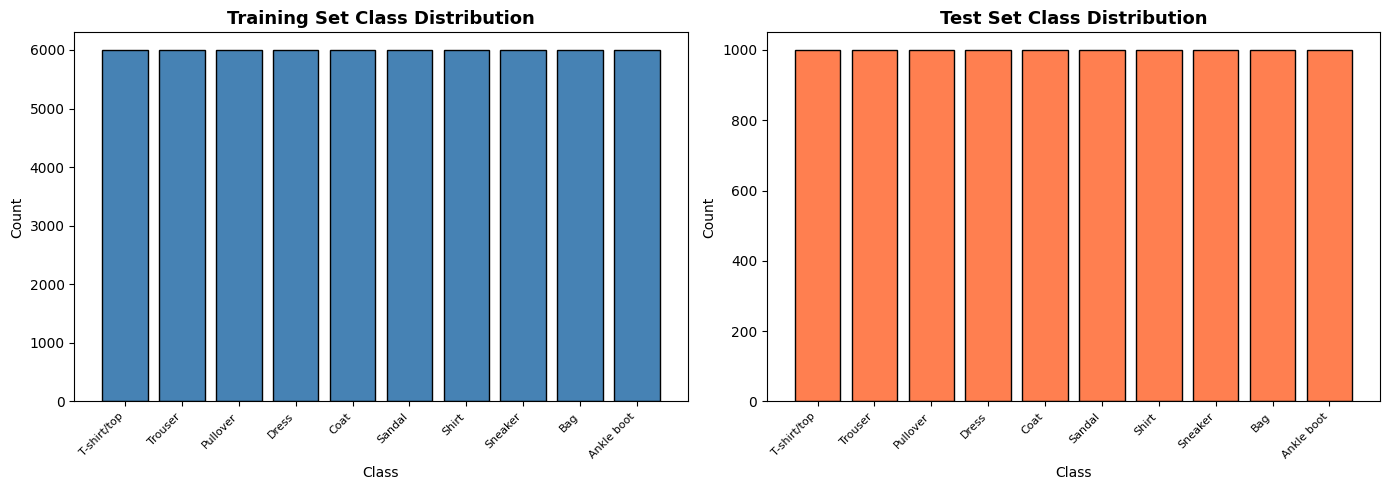


Training set samples per class: {'T-shirt/top': 6000, 'Trouser': 6000, 'Pullover': 6000, 'Dress': 6000, 'Coat': 6000, 'Sandal': 6000, 'Shirt': 6000, 'Sneaker': 6000, 'Bag': 6000, 'Ankle boot': 6000}
Test set samples per class: {'T-shirt/top': 1000, 'Trouser': 1000, 'Pullover': 1000, 'Dress': 1000, 'Coat': 1000, 'Sandal': 1000, 'Shirt': 1000, 'Sneaker': 1000, 'Bag': 1000, 'Ankle boot': 1000}


In [4]:
# Show the distribution of classes in the training and test sets.
# Task 1.4: Visualize class distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
unique_train, counts_train = np.unique(y_train, return_counts=True)
axes[0].bar(range(10), counts_train, color='steelblue', edgecolor='black')
axes[0].set_title('Training Set Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)

# Test set distribution
unique_test, counts_test = np.unique(y_test, return_counts=True)
axes[1].bar(range(10), counts_test, color='coral', edgecolor='black')
axes[1].set_title('Test Set Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print("\nTraining set samples per class:", dict(zip(class_names, counts_train.tolist())))
print("Test set samples per class:", dict(zip(class_names, counts_test.tolist())))

In [5]:
# Normalize the image pixel values and reshape the images for CNN input.
# Task 1.5: Normalize pixel values and reshape for CNN input

# Normalize pixel values from [0, 255] to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print("After Normalization:")
print(f"  Pixel range (train): [{x_train_norm.min()}, {x_train_norm.max()}]")
print(f"  Pixel range (test) : [{x_test_norm.min()}, {x_test_norm.max()}]")

# Reshape images to include channel dimension: (samples, 28, 28) -> (samples, 28, 28, 1)
x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

print(f"\nAfter Reshaping for CNN:")
print(f"  x_train_cnn shape: {x_train_cnn.shape}")
print(f"  x_test_cnn shape : {x_test_cnn.shape}")

# One-hot encode the labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"\nAfter One-Hot Encoding:")
print(f"  y_train_cat shape: {y_train_cat.shape}")
print(f"  y_test_cat shape : {y_test_cat.shape}")
print(f"  Example label (class {y_train[0]}): {y_train_cat[0]}")

After Normalization:
  Pixel range (train): [0.0, 1.0]
  Pixel range (test) : [0.0, 1.0]

After Reshaping for CNN:
  x_train_cnn shape: (60000, 28, 28, 1)
  x_test_cnn shape : (10000, 28, 28, 1)

After One-Hot Encoding:
  y_train_cat shape: (60000, 10)
  y_test_cat shape : (10000, 10)
  Example label (class 9): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


## Part 2: Build and Train a Shallow CNN

Create and train a shallow CNN on the Fashion-MNIST dataset.

**Expected characteristics:**
- 1 or 2 convolution layers
- 1 pooling layer
- Flatten layer
- 1 dense hidden layer
- Output layer

---

In [6]:
# Design and build a shallow CNN architecture for Fashion-MNIST classification.
# Task 2.1: Build the Shallow CNN model

shallow_cnn = Sequential([
    # Convolutional Layer 1: 32 filters, 3x3 kernel
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),

    # Convolutional Layer 2: 64 filters, 3x3 kernel
    Conv2D(64, (3, 3), activation='relu', name='conv2'),

    # Max Pooling Layer
    MaxPooling2D(pool_size=(2, 2), name='maxpool'),

    # Flatten Layer
    Flatten(name='flatten'),

    # Dense Hidden Layer
    Dense(128, activation='relu', name='dense_hidden'),
    Dropout(0.25, name='dropout'),

    # Output Layer
    Dense(10, activation='softmax', name='output')
], name='Shallow_CNN')

# Compile the model
shallow_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print("=" * 60)
print("SHALLOW CNN ARCHITECTURE")
print("=" * 60)
shallow_cnn.summary()

SHALLOW CNN ARCHITECTURE


Model: "Shallow_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool (MaxPooling2D)          │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the shallow CNN model on the training set and evaluate on the test set.
# Task 2.2: Train the Shallow CNN model

print("Training Shallow CNN...")
print("=" * 50)

# Record training time
start_time_shallow = time.time()

history_shallow = shallow_cnn.fit(
    x_train_cnn, y_train_cat,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

end_time_shallow = time.time()
shallow_training_time = end_time_shallow - start_time_shallow

print(f"\nShallow CNN Training Time: {shallow_training_time:.2f} seconds")

Training Shallow CNN...
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 121s 621ms/step - accuracy: 0.8046 - loss: 0.5565 - val_accuracy: 0.8719 - val_loss: 0.3559
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 137s 598ms/step - accuracy: 0.8799 - loss: 0.3348 - val_accuracy: 0.8968 - val_loss: 0.2872
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 141s 591ms/step - accuracy: 0.9025 - loss: 0.2761 - val_accuracy: 0.9033 - val_loss: 0.2633
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 114s 609ms/step - accuracy: 0.9128 - loss: 0.2434 - val_accuracy: 0.9128 - val_loss: 0.2386
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 142s 607ms/step - accuracy: 0.9211 - loss: 0.2169 - val_accuracy: 0.9155 - val_loss: 0.2332
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 112s 594ms/step - accuracy: 0.9272 - loss: 0.1957 - val_accuracy: 0.9208 - val_loss: 0.2190
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 144s 604ms/step - accuracy: 0.9355 - loss: 0.1755 - val_accuracy: 0.9214 - val_loss: 0.2266
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 113s 601ms/s

In [8]:
# Evaluate the shallow CNN on the test set and report the final test accuracy.
# Task 2.3: Evaluate Shallow CNN on test set

shallow_test_loss, shallow_test_acc = shallow_cnn.evaluate(x_test_cnn, y_test_cat, verbose=0)

print("=" * 50)
print("SHALLOW CNN - TEST SET EVALUATION")
print("=" * 50)
print(f"Test Loss    : {shallow_test_loss:.4f}")
print(f"Test Accuracy: {shallow_test_acc:.4f} ({shallow_test_acc*100:.2f}%)")

SHALLOW CNN - TEST SET EVALUATION
Test Loss    : 0.2445
Test Accuracy: 0.9204 (92.04%)


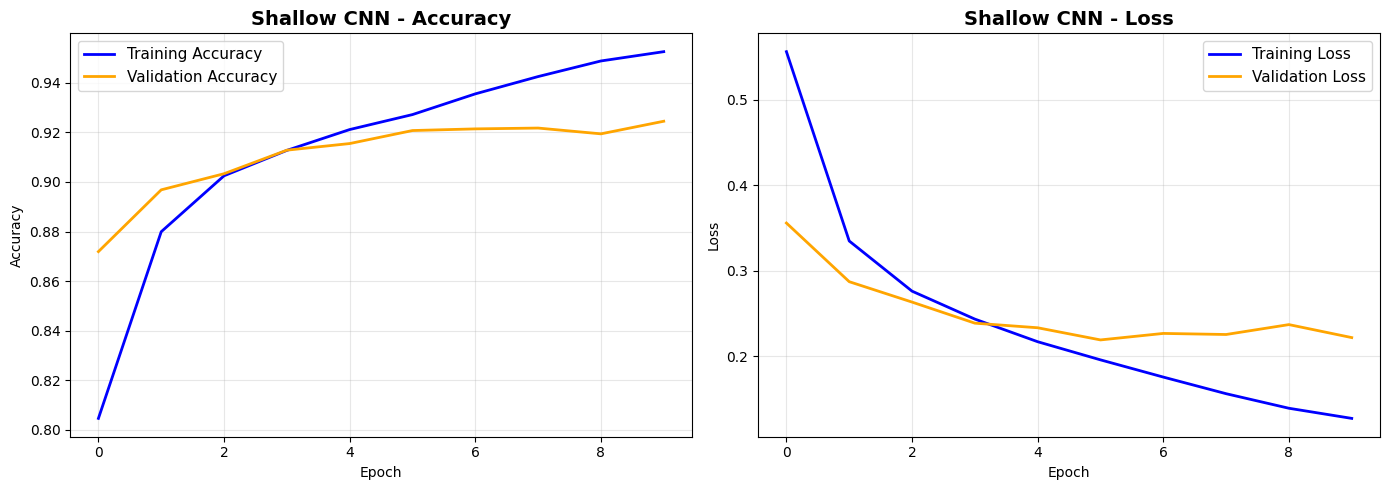


Final Training Accuracy  : 0.9526
Final Validation Accuracy: 0.9245
Final Training Loss      : 0.1271
Final Validation Loss    : 0.2217


In [9]:
# Plot training accuracy, validation accuracy, training loss, and validation loss for the shallow CNN.
# Task 2.4: Plot training and validation curves for Shallow CNN

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(history_shallow.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
axes[0].plot(history_shallow.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
axes[0].set_title('Shallow CNN - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss Plot
axes[1].plot(history_shallow.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[1].plot(history_shallow.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
axes[1].set_title('Shallow CNN - Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy  : {history_shallow.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_shallow.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss      : {history_shallow.history['loss'][-1]:.4f}")
print(f"Final Validation Loss    : {history_shallow.history['val_loss'][-1]:.4f}")

## Part 3: Build and Train a Deep CNN

Create and train a deep CNN on the same Fashion-MNIST dataset.

**Expected characteristics:**
- 3 or more convolution layers
- Multiple pooling layers
- More filters than the shallow CNN
- One or more dense layers
- Output layer

---

In [10]:
# Design and build a deep CNN architecture with 3+ convolution layers for Fashion-MNIST classification.
# Task 3.1: Build the Deep CNN model

deep_cnn = Sequential([
    # Block 1: Convolution + Convolution + Pooling
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1), name='conv1_block1'),
    BatchNormalization(name='bn1'),
    Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2_block1'),
    BatchNormalization(name='bn2'),
    MaxPooling2D(pool_size=(2, 2), name='maxpool_block1'),
    Dropout(0.25, name='dropout_block1'),

    # Block 2: Convolution + Convolution + Pooling
    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv1_block2'),
    BatchNormalization(name='bn3'),
    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2_block2'),
    BatchNormalization(name='bn4'),
    MaxPooling2D(pool_size=(2, 2), name='maxpool_block2'),
    Dropout(0.25, name='dropout_block2'),

    # Flatten
    Flatten(name='flatten'),

    # Dense Layers
    Dense(256, activation='relu', name='dense_hidden1'),
    BatchNormalization(name='bn5'),
    Dropout(0.5, name='dropout_dense1'),

    Dense(128, activation='relu', name='dense_hidden2'),
    Dropout(0.3, name='dropout_dense2'),

    # Output Layer
    Dense(10, activation='softmax', name='output')
], name='Deep_CNN')

# Compile the model
deep_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print("=" * 60)
print("DEEP CNN ARCHITECTURE")
print("=" * 60)
deep_cnn.summary()

DEEP CNN ARCHITECTURE


Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_block1 (Conv2D)           │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 28, 28, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_block1 (Conv2D)           │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 28, 28, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block1 (MaxPooling2D)   │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_block1 (Dropout)        │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_block2 (Conv2D)           │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 14, 14, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_block2 (Conv2D)           │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 14, 14, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block2 (MaxPooling2D)   │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_block2 (Dropout)        │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden1 (Dense)           │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense1 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden2 (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense2 (Dropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,901,642 (7.25 MB)

 Trainable params: 1,900,362 (7.25 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
# Train the deep CNN model on the training set and evaluate on the test set.
# Task 3.2: Train the Deep CNN model

print("Training Deep CNN...")
print("=" * 50)

# Record training time
start_time_deep = time.time()

history_deep = deep_cnn.fit(
    x_train_cnn, y_train_cat,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

end_time_deep = time.time()
deep_training_time = end_time_deep - start_time_deep

print(f"\nDeep CNN Training Time: {deep_training_time:.2f} seconds")

Training Deep CNN...
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 695s 4s/step - accuracy: 0.8024 - loss: 0.5716 - val_accuracy: 0.4263 - val_loss: 2.1412
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8741 - loss: 0.3567

In [ ]:
# Evaluate the deep CNN on the test set and report the final test accuracy.
# Task 3.3: Evaluate Deep CNN on test set

deep_test_loss, deep_test_acc = deep_cnn.evaluate(x_test_cnn, y_test_cat, verbose=0)

print("=" * 50)
print("DEEP CNN - TEST SET EVALUATION")
print("=" * 50)
print(f"Test Loss    : {deep_test_loss:.4f}")
print(f"Test Accuracy: {deep_test_acc:.4f} ({deep_test_acc*100:.2f}%)")

In [ ]:
# Plot training accuracy, validation accuracy, training loss, and validation loss for the deep CNN.
# Task 3.4: Plot training and validation curves for Deep CNN

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(history_deep.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
axes[0].plot(history_deep.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
axes[0].set_title('Deep CNN - Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss Plot
axes[1].plot(history_deep.history['loss'], label='Training Loss', color='green', linewidth=2)
axes[1].plot(history_deep.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[1].set_title('Deep CNN - Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy  : {history_deep.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_deep.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss      : {history_deep.history['loss'][-1]:.4f}")
print(f"Final Validation Loss    : {history_deep.history['val_loss'][-1]:.4f}")

## Part 4: Comparative Study of Shallow CNN vs Deep CNN

Compare both models on the same dataset and training setup.

**Metrics to compare:**
- Number of convolution layers
- Total parameters
- Training accuracy
- Validation accuracy
- Test accuracy
- Training time
- Signs of overfitting or underfitting

---

In [ ]:
# Create a comparison table comparing Shallow CNN and Deep CNN across all key metrics.
# Task 4.1: Build the comparison table

# Count convolution layers
shallow_conv_layers = sum(1 for layer in shallow_cnn.layers if 'conv' in layer.name.lower())
deep_conv_layers = sum(1 for layer in deep_cnn.layers if 'conv' in layer.name.lower())

# Total parameters
shallow_params = shallow_cnn.count_params()
deep_params = deep_cnn.count_params()

# Training accuracy (final epoch)
shallow_train_acc = history_shallow.history['accuracy'][-1]
deep_train_acc = history_deep.history['accuracy'][-1]

# Validation accuracy (final epoch)
shallow_val_acc = history_shallow.history['val_accuracy'][-1]
deep_val_acc = history_deep.history['val_accuracy'][-1]

# Overfitting check (gap between training and validation accuracy)
shallow_gap = shallow_train_acc - shallow_val_acc
deep_gap = deep_train_acc - deep_val_acc

shallow_overfit = "Yes" if shallow_gap > 0.03 else ("Mild" if shallow_gap > 0.01 else "No")
deep_overfit = "Yes" if deep_gap > 0.03 else ("Mild" if deep_gap > 0.01 else "No")

# Create comparison table
print("=" * 70)
print("         COMPARISON TABLE: SHALLOW CNN vs DEEP CNN")
print("=" * 70)
print(f"{'Metric':<30} {'Shallow CNN':<20} {'Deep CNN':<20}")
print("-" * 70)
print(f"{'Number of Conv Layers':<30} {shallow_conv_layers:<20} {deep_conv_layers:<20}")
print(f"{'Total Parameters':<30} {shallow_params:<20,} {deep_params:<20,}")
print(f"{'Training Accuracy':<30} {shallow_train_acc:<20.4f} {deep_train_acc:<20.4f}")
print(f"{'Validation Accuracy':<30} {shallow_val_acc:<20.4f} {deep_val_acc:<20.4f}")
print(f"{'Test Accuracy':<30} {shallow_test_acc:<20.4f} {deep_test_acc:<20.4f}")
print(f"{'Overfitting Observed?':<30} {shallow_overfit:<20} {deep_overfit:<20}")
print(f"{'Training Time (seconds)':<30} {shallow_training_time:<20.2f} {deep_training_time:<20.2f}")
print("=" * 70)

In [ ]:
# Visualize the comparison between Shallow CNN and Deep CNN side by side.
# Task 4.2: Side-by-side training comparison plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_shallow.history['accuracy'], label='Shallow - Train', color='blue', linestyle='-', linewidth=2)
axes[0].plot(history_shallow.history['val_accuracy'], label='Shallow - Val', color='blue', linestyle='--', linewidth=2)
axes[0].plot(history_deep.history['accuracy'], label='Deep - Train', color='green', linestyle='-', linewidth=2)
axes[0].plot(history_deep.history['val_accuracy'], label='Deep - Val', color='green', linestyle='--', linewidth=2)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss comparison
axes[1].plot(history_shallow.history['loss'], label='Shallow - Train', color='blue', linestyle='-', linewidth=2)
axes[1].plot(history_shallow.history['val_loss'], label='Shallow - Val', color='blue', linestyle='--', linewidth=2)
axes[1].plot(history_deep.history['loss'], label='Deep - Train', color='green', linestyle='-', linewidth=2)
axes[1].plot(history_deep.history['val_loss'], label='Deep - Val', color='green', linestyle='--', linewidth=2)
axes[1].set_title('Loss Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5: Prediction and Error Analysis

Analyze how both models behave on actual predictions.

**Tasks:**
- Generate predictions on the test set for both models.
- Display 5 correctly classified and 5 incorrectly classified images for each model.
- For each prediction, mention the actual label and predicted label.
- Include a confusion matrix for both models.

---

In [ ]:
# Generate predictions on the test set for both models.
# Task 5.1: Generate predictions

# Shallow CNN predictions
y_pred_shallow = shallow_cnn.predict(x_test_cnn, verbose=0)
y_pred_shallow_classes = np.argmax(y_pred_shallow, axis=1)

# Deep CNN predictions
y_pred_deep = deep_cnn.predict(x_test_cnn, verbose=0)
y_pred_deep_classes = np.argmax(y_pred_deep, axis=1)

# Find correct and incorrect predictions
shallow_correct = np.where(y_pred_shallow_classes == y_test)[0]
shallow_incorrect = np.where(y_pred_shallow_classes != y_test)[0]

deep_correct = np.where(y_pred_deep_classes == y_test)[0]
deep_incorrect = np.where(y_pred_deep_classes != y_test)[0]

print(f"Shallow CNN - Correct: {len(shallow_correct)}, Incorrect: {len(shallow_incorrect)}")
print(f"Deep CNN    - Correct: {len(deep_correct)}, Incorrect: {len(deep_incorrect)}")

In [ ]:
# Display 5 correctly classified and 5 incorrectly classified images for the Shallow CNN.
# Task 5.2: Display correct and incorrect predictions for Shallow CNN

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Shallow CNN - 5 Correct Predictions (Top Row) & 5 Incorrect Predictions (Bottom Row)',
             fontsize=14, fontweight='bold')

# 5 Correct predictions
np.random.seed(42)
correct_indices = np.random.choice(shallow_correct, 5, replace=False)
for i, idx in enumerate(correct_indices):
    axes[0, i].imshow(x_test[idx], cmap='gray')
    axes[0, i].set_title(f'Actual: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_shallow_classes[idx]]}',
                         fontsize=9, color='green')
    axes[0, i].axis('off')

# 5 Incorrect predictions
incorrect_indices = np.random.choice(shallow_incorrect, 5, replace=False)
for i, idx in enumerate(incorrect_indices):
    axes[1, i].imshow(x_test[idx], cmap='gray')
    axes[1, i].set_title(f'Actual: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_shallow_classes[idx]]}',
                         fontsize=9, color='red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Display 5 correctly classified and 5 incorrectly classified images for the Deep CNN.
# Task 5.3: Display correct and incorrect predictions for Deep CNN

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Deep CNN - 5 Correct Predictions (Top Row) & 5 Incorrect Predictions (Bottom Row)',
             fontsize=14, fontweight='bold')

# 5 Correct predictions
np.random.seed(42)
correct_indices = np.random.choice(deep_correct, 5, replace=False)
for i, idx in enumerate(correct_indices):
    axes[0, i].imshow(x_test[idx], cmap='gray')
    axes[0, i].set_title(f'Actual: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_deep_classes[idx]]}',
                         fontsize=9, color='green')
    axes[0, i].axis('off')

# 5 Incorrect predictions
incorrect_indices = np.random.choice(deep_incorrect, 5, replace=False)
for i, idx in enumerate(incorrect_indices):
    axes[1, i].imshow(x_test[idx], cmap='gray')
    axes[1, i].set_title(f'Actual: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_deep_classes[idx]]}',
                         fontsize=9, color='red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Generate and display confusion matrices for both models.
# Task 5.4: Confusion Matrices for both models

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Shallow CNN Confusion Matrix
cm_shallow = confusion_matrix(y_test, y_pred_shallow_classes)
sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Shallow CNN - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Deep CNN Confusion Matrix
cm_deep = confusion_matrix(y_test, y_pred_deep_classes)
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Deep CNN - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Print detailed classification reports for both models.
# Task 5.5: Classification Reports

print("=" * 70)
print("SHALLOW CNN - CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, y_pred_shallow_classes, target_names=class_names))

print("\n")
print("=" * 70)
print("DEEP CNN - CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, y_pred_deep_classes, target_names=class_names))

## Part 6: Final Comparative Conclusion

Write a short conclusion based on your full experiment.

---

In [ ]:
# Summarize the final comparison results between both models.
# Task 6.1: Final Summary

print("=" * 70)
print("           FINAL COMPARATIVE SUMMARY")
print("=" * 70)
print(f"\n{'Metric':<30} {'Shallow CNN':<20} {'Deep CNN':<20}")
print("-" * 70)
print(f"{'Conv Layers':<30} {shallow_conv_layers:<20} {deep_conv_layers:<20}")
print(f"{'Total Parameters':<30} {shallow_params:<20,} {deep_params:<20,}")
print(f"{'Test Accuracy':<30} {shallow_test_acc*100:<19.2f}% {deep_test_acc*100:<19.2f}%")
print(f"{'Training Time':<30} {shallow_training_time:<19.2f}s {deep_training_time:<19.2f}s")
print(f"{'Overfitting':<30} {shallow_overfit:<20} {deep_overfit:<20}")
print("-" * 70)

improvement = (deep_test_acc - shallow_test_acc) * 100
print(f"\nAccuracy Improvement (Deep over Shallow): +{improvement:.2f}%")
print(f"Parameter Increase: {deep_params/shallow_params:.1f}x more parameters")
print(f"Training Time Increase: {deep_training_time/shallow_training_time:.1f}x longer")